In [1]:
import asyncio
import logging

# This demo uses Academy to launch agents on Polaris
import academy
from academy.manager import Manager
from academy.agent import Agent, action
from academy.handle import Handle
from academy.exchange.cloud import HttpExchangeFactory
from academy.logging import init_logging

# We use Globus Compute to launch Academy Agents on Polaris
from globus_compute_sdk import Executor as GlobusComputeExecutor

print(academy.__version__)

0.4.0


In [2]:
# Get tokens for the Argonne Inference Endpoint. This step will emit a Globus Auth URL that 
# will take you to an authentication page. 
# NOTE: You need to auth an ALCF/UChicago account to use the Argonne Inference Endpoint

from inference_auth_token import get_access_token
api_key = get_access_token()

In [3]:
# Please note that this is a work in **progress**
class DrugReasoner(Agent):
    
    def __init__(self, api_key: str, model_name: str='openai/gpt-oss-120b', 
                 base_url='https://inference-api.alcf.anl.gov/resource_server/sophia/vllm/v1'):
        super().__init__()
        self.model_name = model_name
        self.base_url = base_url
        self.api_key = api_key
        self.llm = None
        
        
    async def agent_on_startup(self):
        from langchain_openai import ChatOpenAI
        
        self.llm = ChatOpenAI(
            model=self.model_name,
            api_key=self.api_key,
            base_url=self.base_url,
        )


    def _parse_json_response(self, text: str):
        """Strip markdown fences (if any) and parse JSON."""
        import json
        
        cleaned = text.strip()
        if cleaned.startswith("```"):
            # Remove opening fence (```json or ```)
            cleaned = cleaned.split("\n", 1)[-1]
        if cleaned.endswith("```"):
            cleaned = cleaned.rsplit("```", 1)[0]
        return json.loads(cleaned.strip())
        
    @action
    async def generate_candidates(self, target_description: str, n: int = 5) -> list[dict]:
        """Ask the LLM to generate candidate drug-like SMILES for a target."""
        
        prompt = f"""You are a medicinal chemist AI.
Generate {n} small-molecule drug candidates targeting: {target_description}

Rules:
- Each molecule must be drug-like (Lipinski's Rule of Five)
- Prefer known pharmacophores for this target class
- Return ONLY valid JSON, no preamble, no markdown fences

Return a JSON array of objects with these fields:
  "smiles"      : valid SMILES string
  "name"        : short descriptive name
  "rationale"   : one sentence explaining why this scaffold is promising

Example format:
[
  {{"smiles": "CCO", "name": "ethanol", "rationale": "Simple example."}}
]
"""
        try:
            response = self.llm.invoke(prompt)
            candidates = self._parse_json_response(response.content)
        except Exception as e:
            return f"Failed to connect to inference endpoint with {self.api_key}: error:{e}"
        
        return candidates
    
    @action
    async def select_lead(self, candidates: list[dict]) -> dict:
        """Pick the best candidate"""
        import json
        summaries = [
        {
            "name":          c["name"],
            "smiles":        c["smiles"],
            "rationale":     c["rationale"],
            "mw":            c.get("mw"),
            "logp":          c.get("logp"),
            "tpsa":          c.get("tpsa"),
            "lipinski_ok":   c.get("lipinski_ok"),
            "strain_energy_kJ_mol": c.get("strain_energy"),
        }
        for c in candidates if "strain_energy" in c
        ]

        prompt = f"""You are an expert computational medicinal chemist.
Below are drug candidates with computed properties and strain energies.
Lower strain energy indicates a more geometrically relaxed, binding-ready ligand.

Pick the single best lead candidate, balancing:
- Low strain energy (flexible, ready to bind)
- Good drug-likeness (Lipinski compliant, low TPSA)
- Chemical novelty and rationale quality

Return ONLY valid JSON with fields:
  "lead_name"  : name of chosen candidate
  "reasoning"  : 2-3 sentence explanation of the choice

Candidates:
{json.dumps(summaries, indent=2)}
"""

        response = self.llm.invoke(prompt)
        lead = self._parse_json_response(response.content)
        return lead

In [4]:
class DrugValidator(Agent):
    
    def __init__(self, ):
        super().__init__()
        
    @action
    async def validate_and_featurize(self, candidates: list[dict]) -> list[dict]:
        """Validate SMILES and compute drug-likeness descriptors."""
        from rdkit import Chem
        from rdkit.Chem import AllChem, Descriptors
        from rdkit.Chem import Draw
        valid = []
        for c in candidates:
            mol = Chem.MolFromSmiles(c["smiles"])
            if mol is None:
                print(f"  ✗ Invalid SMILES skipped: {c['name']}")
                continue

            mol = Chem.AddHs(mol)
            result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
            if result != 0:
                print(f"  ✗ 3D embedding failed: {c['name']}")
                continue
            AllChem.MMFFOptimizeMolecule(mol)

            c["mol"]        = mol
            c["mw"]         = Descriptors.MolWt(mol)
            c["logp"]       = Descriptors.MolLogP(mol)
            c["hbd"]        = Descriptors.NumHDonors(mol)
            c["hba"]        = Descriptors.NumHAcceptors(mol)
            c["tpsa"]       = Descriptors.TPSA(mol)
            c["n_atoms"]    = mol.GetNumAtoms()
            c["lipinski_ok"] = (
                c["mw"] <= 500 and c["logp"] <= 5 and
                c["hbd"] <= 5  and c["hba"] <= 10
            )
            valid.append(c)

        print(f"✓ {len(valid)}/{len(candidates)} candidates passed validation")
        return valid


    # ── Step 3: OpenMM binding energy proxy ───────────────────────
    @action
    async def estimate_binding_energy(self, candidates: list[dict]) -> list[dict]:
        """
        Estimates binding energy proxy via OpenMM vacuum minimization using
        GAFF2 force field from openmmforcefields. Computes strain energy
        (energy before minimization - energy after) as a proxy for
        ligand flexibility / binding readiness.
        """
        from openmmforcefields.generators import GAFFTemplateGenerator
        from openmm.app import ForceField, NoCutoff, Simulation
        from openmm import LangevinMiddleIntegrator, Platform, Vec3
        from openmm.unit import (
            kelvin, femtoseconds, picosecond,
            kilojoules_per_mole, nanometers
        )
        from rdkit.Chem import AllChem
        import numpy as np

        def rdkit_mol_to_openmm(mol):
            """Convert an RDKit mol with a conformer to OpenMM topology + positions."""
            from openmm.app import Topology, Element
            topology = Topology()
            chain    = topology.addChain()
            residue  = topology.addResidue("LIG", chain)

            atom_map = {}
            for atom in mol.GetAtoms():
                elem        = Element.getByAtomicNum(atom.GetAtomicNum())
                omm_atom    = topology.addAtom(atom.GetSymbol(), elem, residue)
                atom_map[atom.GetIdx()] = omm_atom

            for bond in mol.GetBonds():
                topology.addBond(
                    atom_map[bond.GetBeginAtomIdx()],
                    atom_map[bond.GetEndAtomIdx()]
                )

            conf      = mol.GetConformer()
            positions = [
                Vec3(
                    conf.GetAtomPosition(i).x * 0.1,   # Å → nm
                    conf.GetAtomPosition(i).y * 0.1,
                    conf.GetAtomPosition(i).z * 0.1,
                ) * nanometers
                for i in range(mol.GetNumAtoms())
            ]

            return topology, positions

        def get_platform():
            for name in ['CUDA', 'OpenCL', 'CPU']:
                try:
                    return Platform.getPlatformByName(name)
                except Exception:
                    continue

        platform = get_platform()
        print(f"  Using platform: {platform.getName()}")

        for c in candidates:
            try:
                mol = c["mol"]

                # Re-embed to get a fresh starting conformer before minimization
                mol_start = Chem.AddHs(Chem.RemoveHs(mol))
                AllChem.EmbedMolecule(mol_start, AllChem.ETKDGv3())

                # GAFF2 force field
                gaff = GAFFTemplateGenerator(
                    molecules=mol_start,
                    forcefield='gaff-2.11'
                )
                ff = ForceField()
                ff.registerTemplateGenerator(gaff.generator)

                topology, positions = rdkit_mol_to_openmm(mol_start)
                system = ff.createSystem(topology, nonbondedMethod=NoCutoff)

                integrator = LangevinMiddleIntegrator(
                    300 * kelvin,
                    1.0 / picosecond,
                    2.0 * femtoseconds,
                )

                sim = Simulation(topology, system, integrator, platform)
                sim.context.setPositions(positions)

                state_before = sim.context.getState(getEnergy=True)
                e_before     = state_before.getPotentialEnergy().value_in_unit(
                    kilojoules_per_mole
                )

                sim.minimizeEnergy(maxIterations=500)

                state_after = sim.context.getState(getEnergy=True)
                e_after     = state_after.getPotentialEnergy().value_in_unit(
                    kilojoules_per_mole
                )

                c["e_before"]      = round(e_before, 2)
                c["e_after"]       = round(e_after, 2)
                c["strain_energy"] = round(e_before - e_after, 2)

                print(f"  {c['name']:30s}  "
                      f"e_before={e_before:.1f}  "
                      f"e_after={e_after:.1f}  "
                      f"strain={c['strain_energy']:.1f} kJ/mol")

            except Exception as ex:
                print(f"  ✗ Failed for {c['name']}: {ex}")
                c["e_before"]      = None
                c["e_after"]       = None
                c["strain_energy"] = float("inf")

        return candidates

In [5]:
def visualize_results(candidates: list[dict], lead: dict):
    import io
    import math
    import cairosvg
    import matplotlib.pyplot as plt
    from rdkit import Chem
    from rdkit.Chem.Draw import rdMolDraw2D
    from PIL import Image, ImageDraw, ImageFont

    valid = [c for c in candidates if "mol" in c and "strain_energy" in c]

    cell_w, cell_h = 400, 360
    mol_h = 280  # height reserved for the molecule drawing

    def mol_to_pil(mol, size=(cell_w, mol_h)) -> Image.Image:
        drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        svg_bytes = drawer.GetDrawingText().encode()
        png_bytes = cairosvg.svg2png(bytestring=svg_bytes, output_width=size[0], output_height=size[1])
        return Image.open(io.BytesIO(png_bytes)).convert("RGB")

    def make_cell(c) -> Image.Image:
        mol  = Chem.RemoveHs(c["mol"])
        is_lead = c["name"] == lead["lead_name"]

        cell = Image.new("RGB", (cell_w, cell_h), "#1c2128")
        cell.paste(mol_to_pil(mol), (0, 0))

        draw = ImageDraw.Draw(cell)
        try:
            font      = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 13)
            font_bold = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 14)
        except OSError:
            font = font_bold = ImageFont.load_default()

        # legend text block
        name_str   = f"{'★ ' if is_lead else ''}{c['name']}"
        detail_str = f"MW={c['mw']:.0f}  logP={c['logp']:.1f}  strain={c['strain_energy']} kJ/mol"
        name_color = "#f97316" if is_lead else "#e6edf3"

        draw.text((6, mol_h + 4),  name_str,   font=font_bold, fill=name_color)
        draw.text((6, mol_h + 22), detail_str, font=font,      fill="#8b949e")

        # highlight border for lead
        if is_lead:
            for t in range(3):
                draw.rectangle([t, t, cell_w - 1 - t, cell_h - 1 - t], outline="#f97316")

        return cell

    # ── Build grid image ─────────────────────────────────────────
    cols = 3
    rows = math.ceil(len(valid) / cols)
    grid = Image.new("RGB", (cols * cell_w, rows * cell_h), "#0d1117")
    for i, c in enumerate(valid):
        r, col = divmod(i, cols)
        grid.paste(make_cell(c), (col * cell_w, r * cell_h))

    # ── Plot ─────────────────────────────────────────────────────
    grid_w, grid_h = grid.size
    bar_w = 6  # inches for bar chart
    total_w = grid_w / 100 + bar_w
    fig_h = max(grid_h / 100, 4)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(total_w, fig_h),
        facecolor='#0d1117',
        gridspec_kw={"width_ratios": [grid_w / 100, bar_w]}
    )

    axes[0].imshow(grid)
    axes[0].axis('off')
    axes[0].set_title('Candidate Molecules', color='white', fontsize=13, pad=8)
    axes[0].set_facecolor('#0d1117')

    ax = axes[1]
    ax.set_facecolor('#161b22')
    names   = [c["name"] for c in valid]
    strains = [c["strain_energy"] for c in valid]
    colors  = ['#f97316' if n == lead["lead_name"] else '#58a6ff' for n in names]
    bars = ax.barh(names, strains, color=colors, edgecolor='#30363d', height=0.6)
    ax.set_xlabel('Strain Energy (kJ/mol)', color='#aaa', fontsize=11)
    ax.set_title('Strain Energy by Candidate\n(lower = better)', color='white', fontsize=11)
    ax.tick_params(colors='#aaa', labelsize=9)
    ax.xaxis.label.set_color('#aaa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333')

    lead_idx = names.index(lead["lead_name"])
    ax.annotate(
        '★ Lead',
        xy=(strains[lead_idx], lead_idx),
        xytext=(8, 0), textcoords='offset points',
        color='#f97316', fontweight='bold', fontsize=10, va='center'
    )

    fig.patch.set_facecolor('#0d1117')
    plt.tight_layout(pad=2)
    plt.show()

    print(f"\n── Lead Candidate Summary ──────────────────────")
    print(f"  Name   : {lead['lead_name']}")
    print(f"  Reason : {lead['reasoning']}")

Candidates Identified ===================
Erlotinib analog: C#Cc1ccc(cc1)Nc2nccc(Nc3ccc(F)c(Cl)c3)n2
Gefitinib core: COc1ccc2ncnc(Nc3ccc(F)cc3)n2c1
Afatinib‑type irreversible inhibitor: CC(C)N(C)C(=O)C1=CC=C(C=C1)C(=O)N2CCN(CC2)C(=O)C3=NC=CN=C3
2,4‑Diarylpyrimidine scaffold: CC1=NC(=NC=C1)C2=CC=C(C=C2)NC3=NC=NC=N3
Acrylamide‑bearing quinazoline: COc1ccc(cc1)Nc2nccc(Nc3ccc(F)cc3)n2C(=O)C=CC
Validating candidates .... 
Estimating binding energies ...
Identifying lead candidate ...


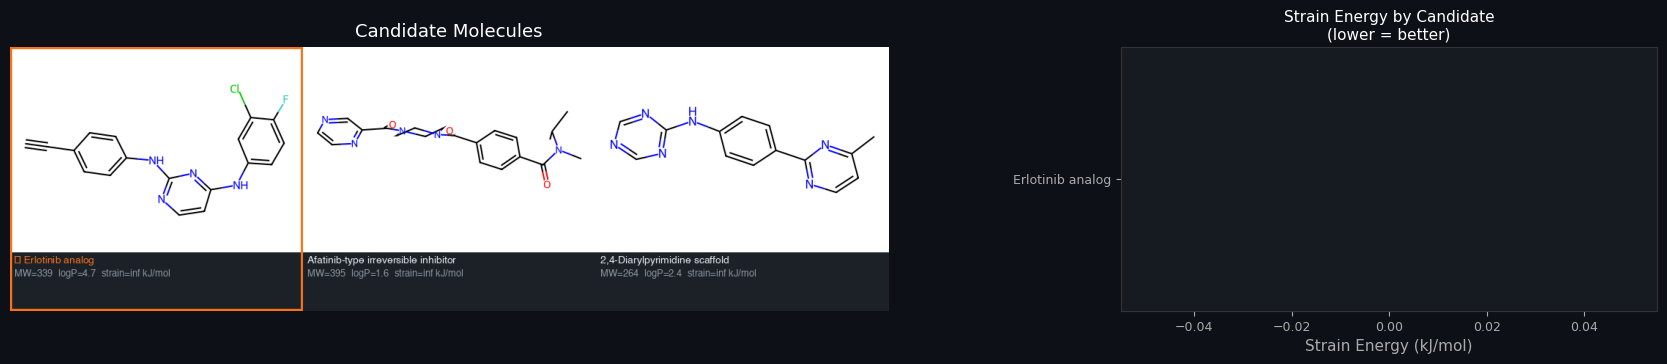


── Lead Candidate Summary ──────────────────────
  Name   : Erlotinib analog
  Reason : The Erlotinib analog offers the lowest polar surface area (~50 Å²) and a moderate molecular weight (≈339 Da), supporting good membrane permeability and oral bioavailability. Its logP is within acceptable drug‑like range and it meets all Lipinski criteria, making it the most balanced candidate despite the missing strain energy data.


In [7]:
# We will use the Polaris Globus Compute Endpoint for launching the two agents
# 
EP_ID = '9a947ba5-f537-4681-acf3-cc66485aadec'
UEP_CONFIG = {'account': "AuroraGPT", 'queue': 'debug', 
              # Polaris MEP is not set to user `worker_init`, but oddly `config_key` to set env
              'config_key': 'source /home/yadunand/setup_openmm.sh; which python3'}


candidates = None
lead_candidate = None

async def drug_finder():
    
    # init_logging(logging.INFO)
    with GlobusComputeExecutor(endpoint_id=EP_ID, 
                               user_endpoint_config=UEP_CONFIG,
                              ) as remote_exec:
        # Create manager with agents and their assigned executors
        async with await Manager.from_exchange_factory(
            factory=HttpExchangeFactory(),
            executors=remote_exec,
        ) as manager:
            drug_reasoner = await manager.launch(DrugReasoner, args=(api_key,))
            drug_validator = await manager.launch(DrugValidator)

            candidates = await drug_reasoner.generate_candidates("kinase inhibitor targeting EGFR for NSCLC")
            print("Candidates Identified ===================")
            for c in candidates:
                print(f"{c['name']}: {c['smiles']}")
            print("=========================================")

            print("Validating candidates .... ")                
            validated_candidates = await drug_validator.validate_and_featurize(candidates)
            
            print("Estimating binding energies ...")
            
            simulated_candidates = await drug_validator.estimate_binding_energy(validated_candidates)
            
            print("Identifying lead candidate ...")
            lead_candidate = await drug_reasoner.select_lead(simulated_candidates)
            
            visualize_results(simulated_candidates, lead_candidate)
        remote_exec.shutdown(wait=True)

await drug_finder()